# Predicción de Inasistencias a Consultas Médicas

**Diploma de Especialización en Ciencias de Datos e Inteligencia Artificial - UTEC**  
**25 de febrero de 2026**  
**Tomás Clavijo**

## 1. Introducción

### 1.1 Contexto del problema

El ausentismo a consultas médicas programadas, comúnmente denominado *no-show* es un problema estructural en los sistemas de salud. Cuando un paciente agenda una cita y no se presenta sin cancelar previamente, las consecuencias se acumulan en múltiples dimensiones:

- **Económica:** horas de personal médico desperdiciadas e infraestructura ociosa que representan costos sin retorno.
- **Operativa:** turnos que podrían haber sido reasignados a otros pacientes quedan vacíos, aumentando los tiempos de espera generales.
- **Sanitaria:** el propio paciente posterga su diagnóstico o tratamiento, agravando potencialmente su condición y generando mayor carga futura al sistema.

Una ciudad de Brasil, enfrentando este problema, implementó un plan piloto de envío de SMS recordatorios a sus pacientes. Sin embargo, los resultados no fueron satisfactorios. Frente a esto, se solicita un enfoque basado en datos: construir un modelo de Machine Learning que, al momento de realizarse una reserva, pueda predecir si el paciente faltará o no a la consulta

### 1.2 Objetivo

Desarrollar un modelo de clasificación binaria que estime la probabilidad de inasistencia de un paciente a partir de la información disponible en el momento de la reserva. Un modelo de este tipo permitiría al sistema de salud tomar acciones preventivas focalizadas sobre los pacientes de mayor riesgo: llamadas de confirmación, sobre-reservas controladas, o reasignación dinámica de turnos.


### 1.3 Plan de trabajo

El desarrollo del proyecto sigue estas etapas:

1. Exploración y limpieza del dataset
2. Ingeniería de variables (*feature engineering*)
3. Entrenamiento de al menos dos modelos de clasificación
4. Optimización de hiperparámetros
5. Evaluación con métricas adecuadas al problema
6. Análisis y discusión de resultados

## 2. Descripción del dataset

### 2.1 Carga de datos


In [1]:
# Importación de librerías

# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Imports para modelado
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Instalación de XGBoost
!pip install xgboost -q
from xgboost import XGBClassifier

# Instalación de LightGBM
!pip install lightgbm -q
import lightgbm as lgb

# Optimización de hiperparámetros
from sklearn.model_selection import RandomizedSearchCV

# Análisis de umbral
from sklearn.metrics import precision_recall_curve, f1_score

# Shap
!pip install shap -q
import shap

# Validación cruzada
from sklearn.model_selection import StratifiedKFold, cross_validate

# Configuración general
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

In [2]:
# Carga del archivo

df = pd.read_excel('/content/FaltasConsultasMedicas.xlsx')
print(f"Dataset cargado exitosamente: {df.shape[0]:,} filas × {df.shape[1]} columnas")

Dataset cargado exitosamente: 110,527 filas × 14 columnas


In [3]:
# Vista previa del dataset
df.head()

,PatientId,AppointmentID,Gender,FechaReserva,FechaConsulta,Edad,Barrio,Becado,Hipertension,Diabetes,Alcoholismo,Discapacidad,Recibió SMS,Falta a consulta
0,29872500000000,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,558998000000000,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4262960000000,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,867951000000,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8841190000000,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [4]:
# Valores nulos

print(f"Valores nulos totales: {df.isnull().sum().sum()}")
print(df.isnull().sum().to_string())

Valores nulos totales: 0
PatientId           0
AppointmentID       0
Gender              0
FechaReserva        0
FechaConsulta       0
Edad                0
Barrio              0
Becado              0
Hipertension        0
Diabetes            0
Alcoholismo         0
Discapacidad        0
Recibió SMS         0
Falta a consulta    0


**Observaciones**

- No se presentan valores nulos en el dataset.

### 2.2 Diccionario de variables

In [5]:
# Tipos de datos
display(df.dtypes)

# Valores únicos por columna
display(df.nunique())

# Valores de las columnas categóricas y binarias
for col in ['Gender', 'Becado', 'Hipertension', 'Diabetes', 'Alcoholismo', 'Discapacidad', 'Recibió SMS', 'Falta a consulta']:
    valores = df[col].unique().tolist()
    print(f"{col}: {sorted(valores)}")

,0
PatientId,int64
AppointmentID,int64
Gender,object
FechaReserva,object
FechaConsulta,object
Edad,int64
Barrio,object
Becado,int64
Hipertension,int64
Diabetes,int64


,0
PatientId,61744
AppointmentID,110527
Gender,2
FechaReserva,103549
FechaConsulta,27
Edad,104
Barrio,81
Becado,2
Hipertension,2
Diabetes,2


Gender: ['F', 'M']
Becado: [0, 1]
Hipertension: [0, 1]
Diabetes: [0, 1]
Alcoholismo: [0, 1]
Discapacidad: [0, 1, 2, 3, 4]
Recibió SMS: [0, 1]
Falta a consulta: ['No', 'Yes']


| Variable | Tipo | Descripción |
|---|---|---|
| `PatientId` | ID numérico | Identificador único del paciente |
| `AppointmentID` | ID numérico | Identificador único de la cita médica |
| `Gender` | Categórica | Sexo del paciente (`F` = femenino, `M` = masculino) |
| `FechaReserva` | Datetime | Fecha y hora en que el paciente realizó la reserva |
| `FechaConsulta` | Datetime | Fecha programada para la consulta |
| `Edad` | Numérica | Edad del paciente en años |
| `Barrio` | Categórica | Barrio de residencia (81 barrios distintos) |
| `Becado` | Binaria (0/1) | Si el paciente es beneficiario de *Bolsa Família* (programa de asistencia social) |
| `Hipertension` | Binaria (0/1) | Si tiene diagnóstico de hipertensión |
| `Diabetes` | Binaria (0/1) | Si tiene diagnóstico de diabetes |
| `Alcoholismo` | Binaria (0/1) | Si tiene diagnóstico de alcoholismo |
| `Discapacidad` | Ordinal (0–4) | Grado de discapacidad registrado |
| `Recibió SMS` | Binaria (0/1) | Si se le envió un SMS recordatorio de la cita |
| **`Falta a consulta`** | **Binaria (Yes/No)** | **Variable objetivo (*target*): si el paciente faltó a la consulta** |

### 2.3 Exploración del dataset

In [6]:
# Estadísticas descriptivas de variables numéricas

df[['Edad']].describe()

,Edad
count,110527.000000
mean,37.088874
std,23.110205
min,-1.000000
25%,18.000000
50%,37.000000
75%,55.000000
max,115.000000


**Observaciones**
- La Edad tiene un valor mínimo de **-1**, lo que indica al menos un registro inválido que deberá corregirse.
- La edad máxima es 115 años, valor cuestionable pero no necesariamente erróneo.

In [7]:
# Distribución de variables categóricas y binarias

for col in ['Gender', 'Becado', 'Hipertension', 'Diabetes', 'Alcoholismo', 'Discapacidad', 'Recibió SMS']:
    print()
    print(df[col].value_counts().to_string())


Gender
F    71840
M    38687

Becado
0    99666
1    10861

Hipertension
0    88726
1    21801

Diabetes
0    102584
1      7943

Alcoholismo
0    107167
1      3360

Discapacidad
0    108286
1      2042
2       183
3        13
4         3

Recibió SMS
0    75045
1    35482


**Observaciones:**
- **Gender:** mayoría femenina (65%).
- **Condiciones médicas:** baja prevalencia general , Hipertensión es la más frecuente (20%), seguida de Diabetes (7%) y Alcoholismo (3%).
- **Becado:** el 10% de los pacientes son beneficiarios del programa de asistencia social.
- **Discapacidad:** el 98% de los pacientes tiene valor 0; los grados 3 y 4 son prácticamente inexistentes.
- **Recibió SMS:** 32% de los pacientes recibieron recordatorio por SMS.

In [8]:
# Distribución de la variable objetivo

print(df['Falta a consulta'].value_counts())
print()
print("Proporciones:")
print(df['Falta a consulta'].value_counts(normalize=True).apply(lambda x: f"{x*100:.1f}%"))

Falta a consulta
No     88208
Yes    22319
Name: count, dtype: int64

Proporciones:
Falta a consulta
No     79.8%
Yes    20.2%
Name: proportion, dtype: object


**Observaciones:**
- 88,208 pacientes asistieron a su consulta (79.8%) y 22,319 faltaron (20.2%).
- El dataset está desbalanceado con un ratio de aproximadamente 4:1.

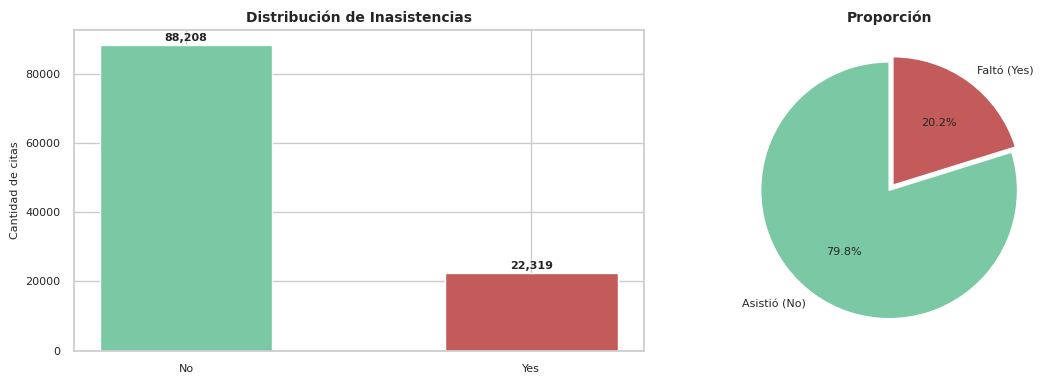

In [9]:
# Visualización del desbalance de clases

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target_counts = df['Falta a consulta'].value_counts()
colores = ['#7bc8a4', '#c45b5b']

# Barras
bars = axes[0].bar(target_counts.index, target_counts.values, color=colores, width=0.5)
for bar, cnt in zip(bars, target_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1200,
                 f'{cnt:,}', ha='center', fontweight='bold', fontsize=8)
axes[0].set_title('Distribución de Inasistencias', fontweight='bold', fontsize=10)
axes[0].set_ylabel('Cantidad de citas', fontsize=8)
axes[0].tick_params(labelsize=8)

# Torta
axes[1].pie(target_counts.values, labels=['Asistió (No)', 'Faltó (Yes)'],
            autopct='%1.1f%%', colors=colores, startangle=90, explode=(0, 0.05),
            textprops={'fontsize': 8})
axes[1].set_title('Proporción', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

**Observaciones:**

Como ya se mencionó, se observa que el dataset está desbalanceado, con 80% de asistencias y 20% de inasistencias. Esto tiene implicancias directas para el modelado:
- Un clasificador trivial que siempre prediga "No falta" tendría 80% de accuracy pero sería completamente inútil para el objetivo real.
- Será necesario utilizar métricas sensibles al desbalance (Recall, F1, AUC-ROC) y posiblemente técnicas de balanceo al entrenar los modelos.

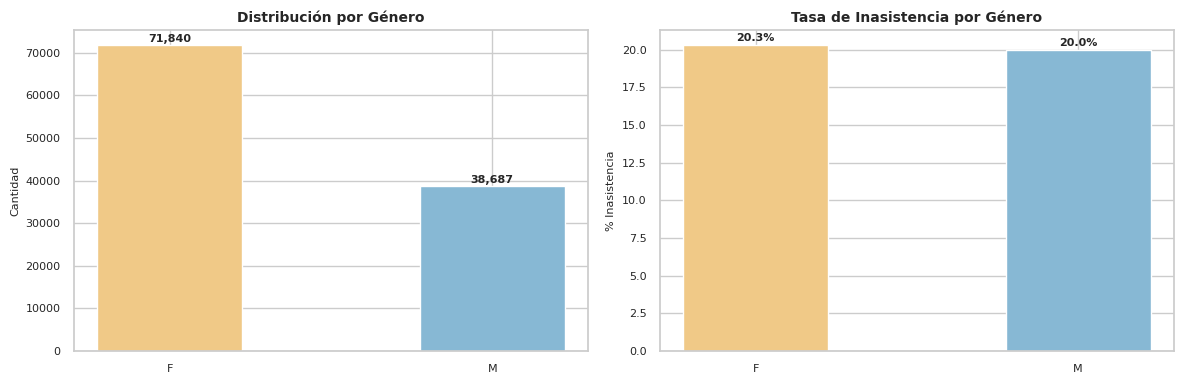

In [10]:
# Tasa de inasistencia por género

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribución por género
gender_counts = df['Gender'].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values, color=['#f0c987', '#87b8d4'], width=0.45)
for i, cnt in enumerate(gender_counts.values):
    axes[0].text(i, cnt + 800, f'{cnt:,}', ha='center', fontweight='bold', fontsize=8)
axes[0].set_title('Distribución por Género', fontweight='bold', fontsize=10)
axes[0].set_ylabel('Cantidad', fontsize=8)
axes[0].tick_params(labelsize=8)

# Tasa de no-show por género
ns_gender = df.groupby('Gender')['Falta a consulta'].apply(lambda x: (x=='Yes').mean()*100)
bars = axes[1].bar(ns_gender.index, ns_gender.values, color=['#f0c987', '#87b8d4'], width=0.45)
for bar, val in zip(bars, ns_gender.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=8)
axes[1].set_title('Tasa de Inasistencia por Género', fontweight='bold', fontsize=10)
axes[1].set_ylabel('% Inasistencia', fontsize=8)
axes[1].tick_params(labelsize=8)

plt.tight_layout()
plt.show()

**Observaciones**
- El dataset tiene mayoría femenina (65% vs 35%), como se observó anteriormente y se visualiza en el gráfico de la izquierda, pero la tasa de inasistencia es prácticamente idéntica entre ambos géneros (20%). El género por sí solo no parece ser un predictor relevante.

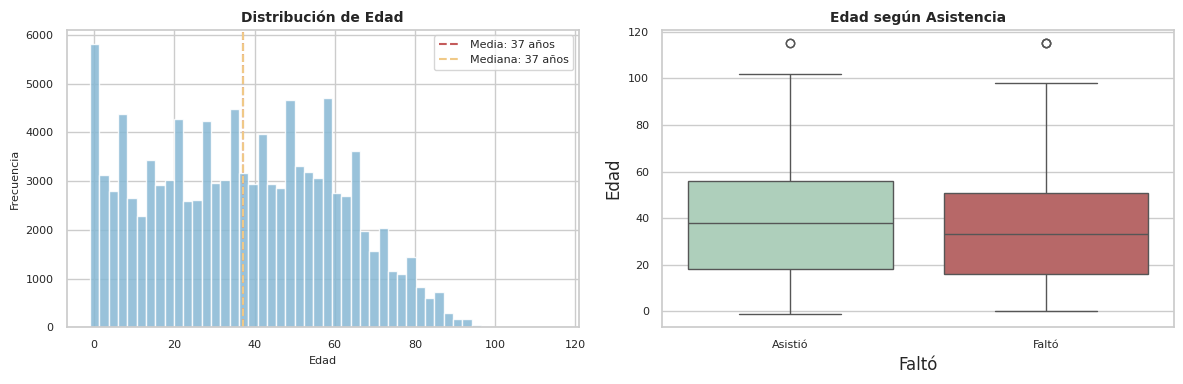


Anomalías: Edad < 0: 1 registro(s) | Edad > 100: 7 registro(s)


In [11]:
# Distribución de edad y su relación con la inasistencia

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma de edad
axes[0].hist(df['Edad'], bins=50, color='#87b8d4', edgecolor='white', alpha=0.85)
axes[0].axvline(df['Edad'].mean(), color='#c45b5b', ls='--', lw=1.5, label=f"Media: {df['Edad'].mean():.0f} años")
axes[0].axvline(df['Edad'].median(), color='#f0c987', ls='--', lw=1.5, label=f"Mediana: {df['Edad'].median():.0f} años")
axes[0].set_title('Distribución de Edad', fontweight='bold', fontsize=10)
axes[0].set_xlabel('Edad', fontsize=8)
axes[0].set_ylabel('Frecuencia', fontsize=8)
axes[0].legend(fontsize=8)
axes[0].tick_params(labelsize=8)

# Boxplot edad vs target
df_plot = df.copy()
df_plot['Faltó'] = df_plot['Falta a consulta'].map({'No': 'Asistió', 'Yes': 'Faltó'})
sns.boxplot(data=df_plot, x='Faltó', y='Edad', ax=axes[1], palette=['#a8d5ba', '#c45b5b'])
axes[1].set_title('Edad según Asistencia', fontweight='bold', fontsize=10)
axes[1].tick_params(labelsize=8)

plt.tight_layout()
plt.show()

print()
print(f"Anomalías: Edad < 0: {(df['Edad']<0).sum()} registro(s) | Edad > 100: {(df['Edad']>100).sum()} registro(s)")

**Observaciones**
- La distribución es amplia, con un pico notable en bebés/niños pequeños (0-2 años) y una media y mediana coincidentes en 37 años.
- El boxplot muestra que los pacientes que faltan tienden a ser levemente más jóvenes (mediana más baja).
- Se detectan anomalías: 1 registro con edad negativa (-1) y 7 registros con edad superior a 100 años, a tratar en la limpieza.

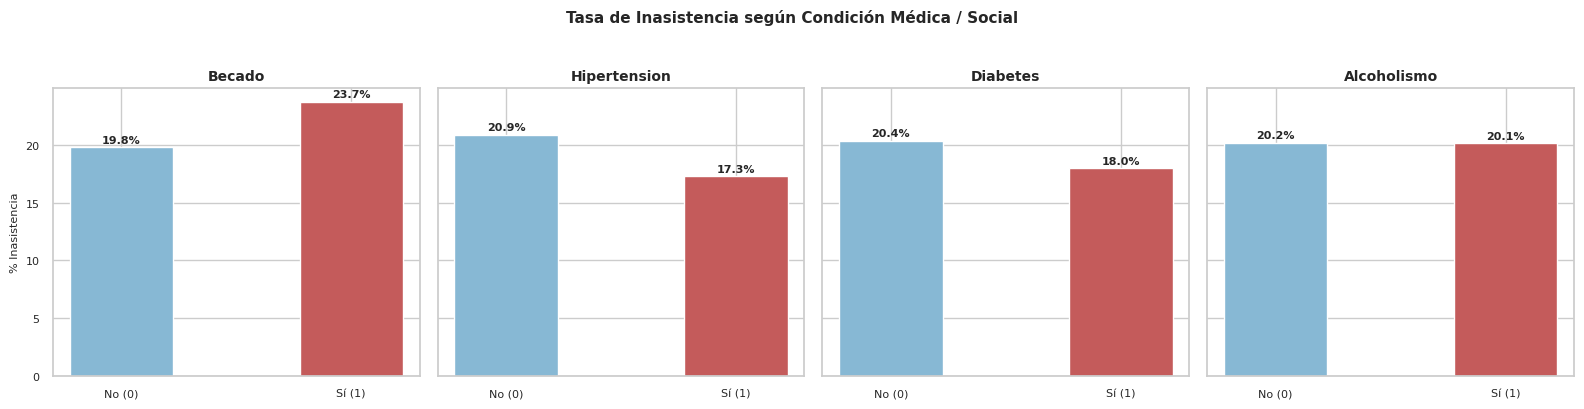

In [12]:
# Tasa de inasistencia por condición médica y programa social

features = ['Becado', 'Hipertension', 'Diabetes', 'Alcoholismo']

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

for i, col in enumerate(features):
    ns_rate = df.groupby(col)['Falta a consulta'].apply(lambda x: (x=='Yes').mean()*100)
    bars = axes[i].bar(['No (0)', 'Sí (1)'], ns_rate.values, color=['#87b8d4', '#c45b5b'], width=0.45)
    for bar, val in zip(bars, ns_rate.values):
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
                     f'{val:.1f}%', ha='center', fontweight='bold', fontsize=8)
    axes[i].set_title(col, fontweight='bold', fontsize=10)
    axes[i].tick_params(labelsize=8)
    if i == 0:
        axes[i].set_ylabel('% Inasistencia', fontsize=8)

plt.suptitle('Tasa de Inasistencia según Condición Médica / Social', fontweight='bold', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

**Observaciones**
- Los pacientes con Hipertensión y Diabetes faltan menos que los que no tienen estas condiciones. Esto puede explicarse por una mayor adherencia al sistema de salud dada la gravedad de sus patologías crónicas.
- Los pacientes Becados faltan más, lo que podría reflejar barreras socioeconómicas como dificultades de transporte u horarios laborales.
- El Alcoholismo no muestra diferencia significativa 20% en ambos casos.

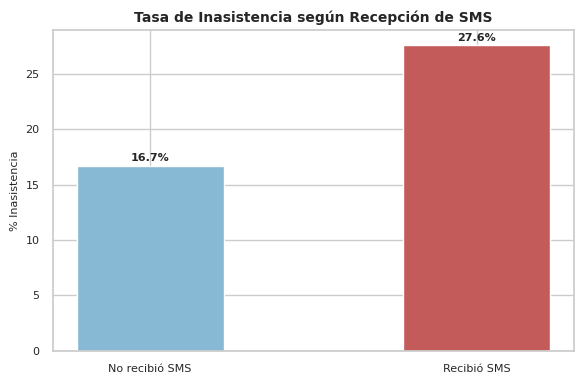

In [13]:
# Tasa de inasistencia según recepción de SMS

ns_sms = df.groupby('Recibió SMS')['Falta a consulta'].apply(lambda x: (x=='Yes').mean()*100)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['No recibió SMS', 'Recibió SMS'], ns_sms.values, color=['#87b8d4', '#c45b5b'], width=0.45)
for bar, val in zip(bars, ns_sms.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=8)
ax.set_title('Tasa de Inasistencia según Recepción de SMS', fontweight='bold', fontsize=10)
ax.set_ylabel('% Inasistencia', fontsize=8)
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

**Observaciones**

Los pacientes que recibieron SMS tienen una tasa de inasistencia mayor (27.6%) que los que no lo recibieron (16.7%). Esto no significa que el SMS cause inasistencias, sino que probablemente refleja un sesgo de selección: los SMS se enviaron preferentemente a pacientes con citas agendadas con mayor anticipación, que ya de por sí tienen mayor probabilidad de faltar.

Esta es una distinción fundamental entre correlación y causalidad que debe tenerse en cuenta tanto al interpretar los datos como al construir los modelos. La variable Recibió SMS será incluida como feature, pero su coeficiente no debe interpretarse como efecto causal del SMS sobre la inasistencia.

In [14]:
# Días de anticipación entre reserva y consulta

df['FechaReserva'] = pd.to_datetime(df['FechaReserva'])
df['FechaConsulta'] = pd.to_datetime(df['FechaConsulta'])
df['DiasAnticipacion'] = (df['FechaConsulta'].dt.normalize() - df['FechaReserva'].dt.normalize()).dt.days

print(f"Media: {df['DiasAnticipacion'].mean():.1f} días | Mediana: {df['DiasAnticipacion'].median():.0f} días")
print(f"Rango: [{df['DiasAnticipacion'].min()}, {df['DiasAnticipacion'].max()}]")
print(f"Reservas mismo día: {(df['DiasAnticipacion']==0).sum():,} ({(df['DiasAnticipacion']==0).mean()*100:.1f}%)")
print(f"Anticipación negativa (anomalías): {(df['DiasAnticipacion']<0).sum()}")

Media: 10.2 días | Mediana: 4 días
Rango: [-6, 179]
Reservas mismo día: 38,563 (34.9%)
Anticipación negativa (anomalías): 5


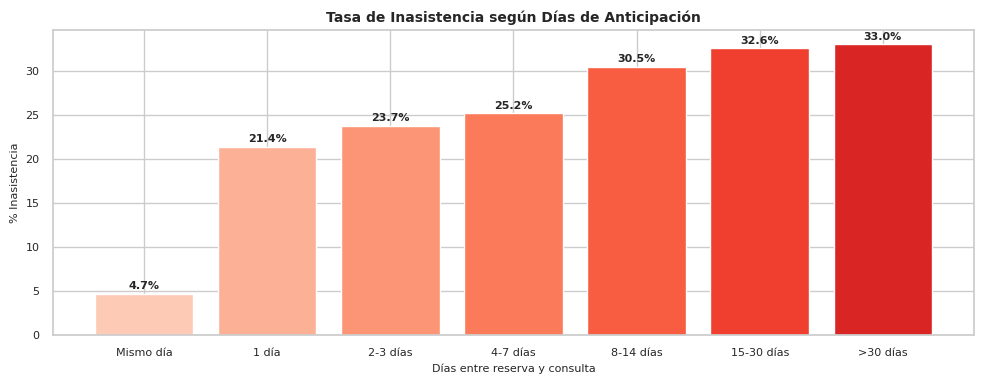

In [15]:
# Tasa de inasistencia por días de anticipación

bins = [-np.inf, 0, 1, 3, 7, 14, 30, np.inf]
labels = ['Mismo día', '1 día', '2-3 días', '4-7 días', '8-14 días', '15-30 días', '>30 días']
df['GrupoAnticipacion'] = pd.cut(df['DiasAnticipacion'], bins=bins, labels=labels)

ns_antic = df.groupby('GrupoAnticipacion', observed=True)['Falta a consulta'].apply(
    lambda x: (x=='Yes').mean()*100
)

fig, ax = plt.subplots(figsize=(10, 4))
cmap = plt.cm.Reds(np.linspace(0.2, 0.7, len(ns_antic)))
bars = ax.bar(ns_antic.index.astype(str), ns_antic.values, color=cmap, edgecolor='white')
for bar, val in zip(bars, ns_antic.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=8)
ax.set_title('Tasa de Inasistencia según Días de Anticipación', fontweight='bold', fontsize=10)
ax.set_ylabel('% Inasistencia', fontsize=8)
ax.set_xlabel('Días entre reserva y consulta', fontsize=8)
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

**Observaciones**
- Esta es la variable con mayor poder predictivo visible. La relación es clara y monótona: a mayor anticipación, mayor inasistencia. Las citas reservadas el mismo día tienen apenas 4.7% de inasistencia, mientras que las de más de 30 días alcanzan 33.0%, casi 7 veces más.
- Se detectan también 5 registros con anticipación negativa (fecha de reserva posterior a la consulta).

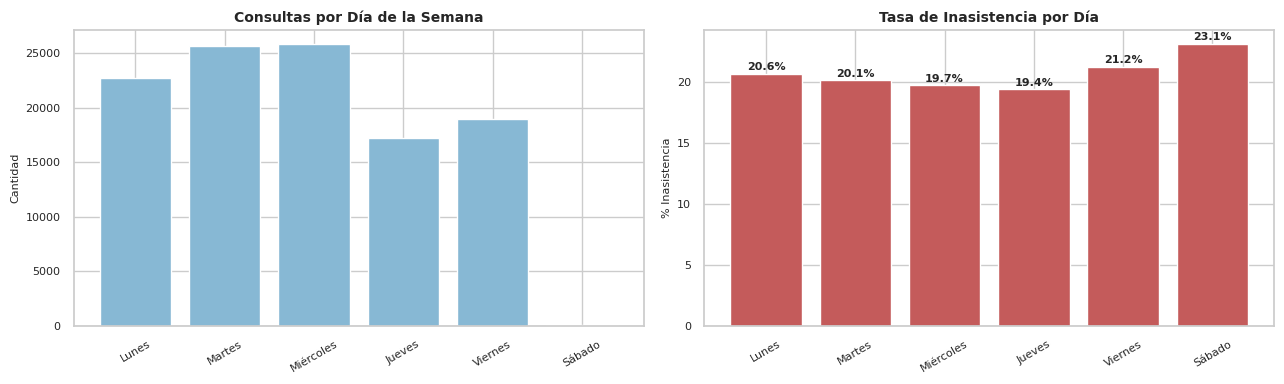

In [16]:
# Tasa de inasistencia por día de la semana

df['DiaSemana'] = df['FechaConsulta'].dt.dayofweek
dias_es = {0:'Lunes', 1:'Martes', 2:'Miércoles', 3:'Jueves', 4:'Viernes', 5:'Sábado', 6:'Domingo'}

ns_dia = df.groupby('DiaSemana')['Falta a consulta'].apply(lambda x: (x=='Yes').mean()*100).sort_index()
cnt_dia = df['DiaSemana'].value_counts().sort_index()
nombres = [dias_es[i] for i in ns_dia.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(nombres, cnt_dia.values, color='#87b8d4', edgecolor='white')
axes[0].set_title('Consultas por Día de la Semana', fontweight='bold', fontsize=10)
axes[0].set_ylabel('Cantidad', fontsize=8)
axes[0].tick_params(axis='x', rotation=30, labelsize=8)
axes[0].tick_params(axis='y', labelsize=8)

bars = axes[1].bar(nombres, ns_dia.values, color='#c45b5b', edgecolor='white')
for bar, val in zip(bars, ns_dia.values):
    if not np.isnan(val):
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                     f'{val:.1f}%', ha='center', fontweight='bold', fontsize=8)
axes[1].set_title('Tasa de Inasistencia por Día', fontweight='bold', fontsize=10)
axes[1].set_ylabel('% Inasistencia', fontsize=8)
axes[1].tick_params(axis='x', rotation=30, labelsize=8)
axes[1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

In [17]:
# Consultas por día de la semana

print(df['DiaSemana'].map({0:'Lunes', 1:'Martes', 2:'Miércoles', 3:'Jueves', 4:'Viernes', 5:'Sábado', 6:'Domingo'}).value_counts().sort_index())

DiaSemana
Jueves       17247
Lunes        22715
Martes       25640
Miércoles    25867
Sábado          39
Viernes      19019
Name: count, dtype: int64


**Observaciones**
- La tasa de inasistencia es relativamente estable entre semana (19-21%), con un leve aumento el sábado (23.1%); aunque no muy significativo debido a la baja cantidad de consultas.
- No hay consultas los domingos.
- La variabilidad es baja, por lo que el día de la semana podría aportar como feature pero con menor poder predictivo que la anticipación.

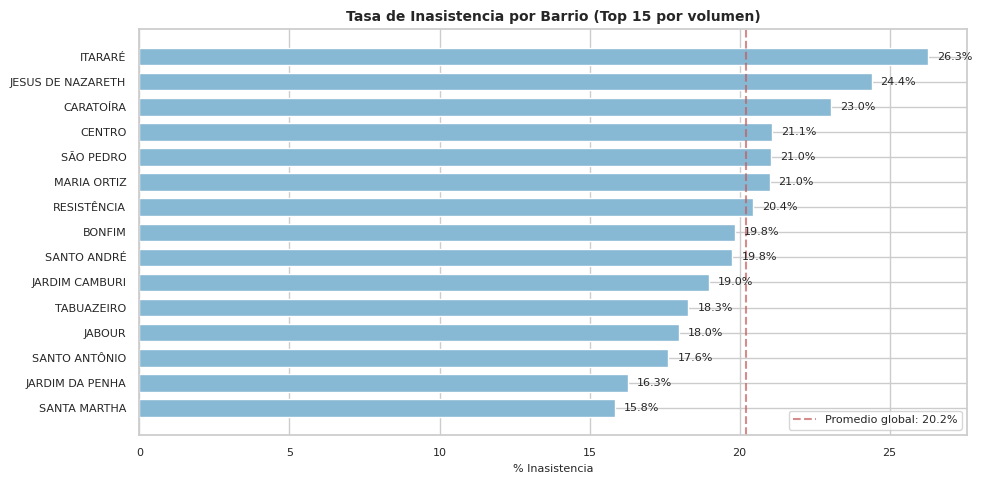

In [18]:
# Tasa de inasistencia por barrio

top15 = df['Barrio'].value_counts().head(15).index
df_top = df[df['Barrio'].isin(top15)]

ns_barrio = df_top.groupby('Barrio')['Falta a consulta'].apply(
    lambda x: (x=='Yes').mean()*100
).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(ns_barrio.index, ns_barrio.values, color='#87b8d4', edgecolor='white', height=0.7)
ax.axvline(20.2, color='#c45b5b', ls='--', lw=1.5, alpha=0.7, label='Promedio global: 20.2%')
for i, val in enumerate(ns_barrio.values):
    ax.text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=8)
ax.set_xlabel('% Inasistencia', fontsize=8)
ax.set_title('Tasa de Inasistencia por Barrio (Top 15 por volumen)', fontweight='bold', fontsize=10)
ax.legend(fontsize=8)
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

**Observaciones**
- Existe variabilidad geográfica, con tasas que van desde 15.8% (Santa Martha) hasta 26.3% (Itararé).
- Barrios como Itararé, Jesus de Nazareth y Caratoíra se ubican consistentemente por encima del promedio global, lo que podría asociarse a factores socioeconómicos o de accesibilidad al centro de salud.


| Hallazgo | Implicancia para el modelado |
|---|---|
| Desbalance 80/20 en el target | Métricas como Recall, F1 y AUC-ROC |
| Sin valores nulos | No requiere imputación |
| 1 edad negativa, 5 anticipaciones negativas | Limpieza puntual de anomalías |
| Días de anticipación como predictor fuerte | Feature engineering clave a partir de las fechas |
| SMS con correlación invertida (sesgo de selección) | Útil como feature pero no como relación causal |
| Hipertensos y diabéticos faltan menos | Condiciones crónicas asociadas a mayor adherencia |
| Becados faltan más | Posibles barreras socioeconómicas |
| Variabilidad por barrio (15.8% a 26.3%) | Considerar encoding del barrio como feature |
| Pacientes repetidos (1.8 citas/paciente promedio) | Potencial para features de historial del paciente |

## 3. Limpieza de datos


A partir de los hallazgos de la exploración, se procede a corregir las anomalías detectadas. El dataset original no tiene valores nulos, por lo que la limpieza se enfoca en registros con valores inconsistentes identificados previamente.

In [19]:
# Registros antes de limpiar

print(f"Registros: {df.shape[0]:,}")

Registros: 110,527


In [20]:
# Edad negativa

print("Registros con edad negativa:")
print(df[df['Edad'] < 0][['PatientId', 'Edad', 'Gender', 'Barrio']].to_string())

Registros con edad negativa:
             PatientId  Edad Gender Barrio
99832  465943000000000    -1      F  ROMÃO


In [21]:
# Anticipación negativa

print("Registros con anticipación negativa:")
print(df[df['DiasAnticipacion'] < 0][['PatientId', 'FechaReserva', 'FechaConsulta', 'DiasAnticipacion']].to_string())

Registros con anticipación negativa:
             PatientId              FechaReserva             FechaConsulta  DiasAnticipacion
27033    7839270000000 2016-05-10 10:51:53+00:00 2016-05-09 00:00:00+00:00                -1
55226    7896290000000 2016-05-18 14:50:41+00:00 2016-05-17 00:00:00+00:00                -1
64175   24252300000000 2016-05-05 13:43:58+00:00 2016-05-04 00:00:00+00:00                -1
71533  998232000000000 2016-05-11 13:49:20+00:00 2016-05-05 00:00:00+00:00                -6
72362    3787480000000 2016-05-04 06:50:57+00:00 2016-05-03 00:00:00+00:00                -1


In [22]:
# Eliminar registros anómalos

df = df[df['Edad'] >= 0]
df = df[df['DiasAnticipacion'] >= 0]

print(f"Registros después de limpieza: {df.shape[0]:,}")
print(f"Registros eliminados: {110527 - df.shape[0]}")

Registros después de limpieza: 110,521
Registros eliminados: 6


Se eliminaron apenas 6 registros (0.005% del dataset). El dataset queda con 110,521 registros limpios para la etapa de feature engineering.

## 4. Feature Engineering

En esta sección se crean nuevas variables derivadas que pueden aportar poder predictivo a los modelos. El feature engineering es una etapa crítica en cualquier proyecto de machine learning: la calidad de las features suele tener mayor impacto en el rendimiento final que la elección del algoritmo.

Las nuevas variables se crean a partir de:
- **Información temporal:** extracción de componentes de las fechas de reserva y consulta.
- **Agrupaciones de edad:** categorización en rangos etarios con significado clínico.
- **Historial del paciente:** aprovechando que hay pacientes con múltiples citas.
- **Codificación de variables categóricas:** transformación de variables textuales a formato numérico para los modelos.

In [23]:
# Variables temporales derivadas
# 0=Lunes ... 6=Domingo

df['DiaSemana'] = df['FechaConsulta'].dt.dayofweek
df['MesConsulta'] = df['FechaConsulta'].dt.month
df['HoraReserva'] = df['FechaReserva'].dt.hour

print("Distribución DiaSemana (0=Lun, 1=Mar, 2=Mié, 3=Jue, 4=Vie, 5=Sáb):")
print(df['DiaSemana'].value_counts().sort_index().to_string())

print("\nDistribución MesConsulta:")
print(df['MesConsulta'].value_counts().sort_index().to_string())

print("\nDistribución HoraReserva:")
print(df['HoraReserva'].value_counts().sort_index().to_string())

Distribución DiaSemana (0=Lun, 1=Mar, 2=Mié, 3=Jue, 4=Vie, 5=Sáb):
DiaSemana
0    22713
1    25638
2    25866
3    17246
4    19019
5       39

Distribución MesConsulta:
MesConsulta
4     3235
5    80836
6    26450

Distribución HoraReserva:
HoraReserva
6      1577
7     19213
8     15348
9     12823
10    11055
11     8462
12     5422
13     9034
14     9126
15     8079
16     5542
17     2909
18     1340
19      488
20      100
21        3


**Observaciones**
- **DiaSemana:** consistente con lo observado en la exploración. Martes y miércoles concentran la mayor cantidad de consultas, mientras que sábado tiene solo 39.
- **MesConsulta:** el dataset abarca 3 meses (abril, mayo y junio de 2016), con mayo concentrando el 73% de las consultas (80,828). Abril y junio tienen datos parciales.
- **HoraReserva:** las reservas se concentran en horario laboral, con pico entre las 7 y las 9 de la mañana. Prácticamente no hay reservas después de las 20hs.

In [24]:
# Rango etario

bins_edad = [-1, 12, 18, 35, 50, 65, 120]
labels_edad = ['Niño', 'Adolescente', 'Adulto joven', 'Adulto', 'Adulto mayor', 'Anciano']
df['RangoEtario'] = pd.cut(df['Edad'], bins=bins_edad, labels=labels_edad)

print("Tasa de inasistencia por rango etario:")
ns_edad = df.groupby('RangoEtario', observed=True)['Falta a consulta'].apply(lambda x: (x=='Yes').mean()*100)
for rango, tasa in ns_edad.items():
    print(f"  {rango}: {tasa:.1f}%")

Tasa de inasistencia por rango etario:
  Niño: 20.5%
  Adolescente: 26.1%
  Adulto joven: 23.8%
  Adulto: 20.3%
  Adulto mayor: 16.5%
  Anciano: 15.5%


**Observaciones**
- Los adolescentes (26.1%) y adultos jóvenes (23.8%) son los grupos con mayor tasa de inasistencia, lo que es consistente con lo observado en el boxplot de edad.
- Los adultos mayores (16.5%) y ancianos (15.5%) son los más adherentes, posiblemente por mayor dependencia del sistema de salud.
- Esta variable captura de forma categórica la relación no lineal entre edad e inasistencia.

In [25]:
# Cantidad de citas previas por paciente

df = df.sort_values(['PatientId', 'FechaConsulta'])
df['CitasPrevias'] = df.groupby('PatientId').cumcount()

print(f"Distribución de citas previas:")
print(df['CitasPrevias'].describe().to_string())

Distribución de citas previas:
count    110521.000000
mean          1.285620
std           3.918246
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          87.000000


**Observaciones**
- La mayoría de los pacientes tienen pocas citas previas: la mediana es 0 y el 75% tiene como máximo 1 cita previa.
- Sin embargo, hay pacientes con hasta 87 citas en el período, lo que indica usuarios frecuentes del sistema.

In [26]:
# Variable objetivo en binario

df['Target'] = (df['Falta a consulta'] == 'Yes').astype(int)

print("Codificación del target:")
print(df['Target'].value_counts().to_string())

Codificación del target:
Target
0    88207
1    22314


In [27]:
# Género en binario

df['Gender_encoded'] = df['Gender'].map({'F': 0, 'M': 1})

print("Codificación de género:")
print(df['Gender_encoded'].value_counts().to_string())

Codificación de género:
Gender_encoded
0    71836
1    38685


In [28]:
# Frecuencia de inasistencia por barrio

barrio_noshow = df.groupby('Barrio')['Target'].mean()
df['Barrio_encoded'] = df['Barrio'].map(barrio_noshow)

print("Top 5 barrios con mayor tasa de inasistencia:")
print(barrio_noshow.sort_values(ascending=False).head().apply(lambda x: f"{x*100:.1f}%").to_string())

Top 5 barrios con mayor tasa de inasistencia:
Barrio
ILHAS OCEÂNICAS DE TRINDADE    100.0%
SANTOS DUMONT                   28.9%
SANTA CECÍLIA                   27.5%
SANTA CLARA                     26.5%
ITARARÉ                         26.3%


In [29]:
# Verificar barrios con pocos registros

print("Barrios con menos de 10 registros:")
barrio_counts = df['Barrio'].value_counts()
print(barrio_counts[barrio_counts < 10].to_string())

Barrios con menos de 10 registros:
Barrio
AEROPORTO                      8
ILHAS OCEÂNICAS DE TRINDADE    2
PARQUE INDUSTRIAL              1


**Observaciones**
- El target encoding asigna a cada barrio su tasa histórica de inasistencia, capturando el efecto geográfico/socioeconómico en una sola variable numérica sin crear 81 columnas.
- **Ilhas Oceânicas de Trindade** muestra 100% de inasistencia, pero con solo 2 registros no es representativo.
- Se identifican 3 barrios con menos de 10 registros (Aeroporto, Ilhas Oceânicas de Trindade, Parque Industrial) cuyo encoding no es confiable y serán eliminados.

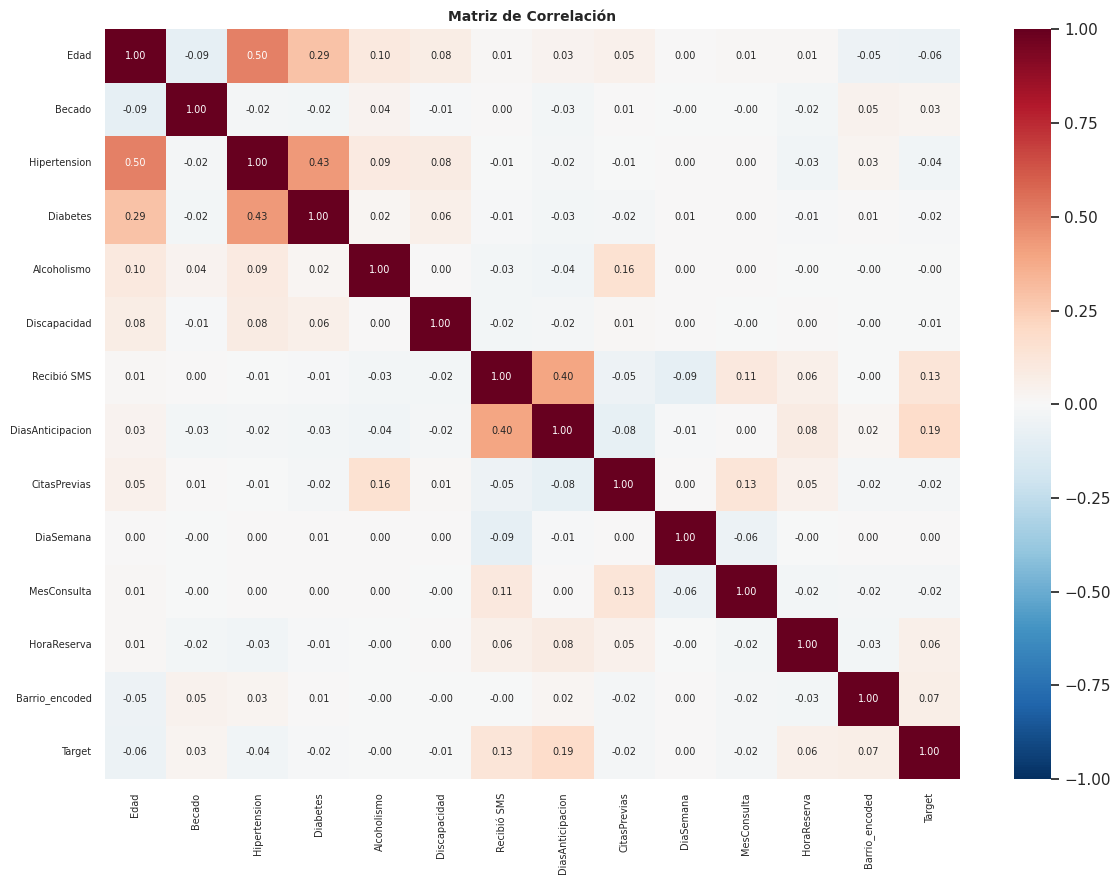

In [30]:
# Matriz de correlación

fig, ax = plt.subplots(figsize=(12, 9))

cols_corr = ['Edad', 'Becado', 'Hipertension', 'Diabetes', 'Alcoholismo',
             'Discapacidad', 'Recibió SMS', 'DiasAnticipacion', 'CitasPrevias',
             'DiaSemana', 'MesConsulta', 'HoraReserva', 'Barrio_encoded', 'Target']
corr = df[cols_corr].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, annot_kws={'fontsize': 7}, vmin=-1, vmax=1)
ax.set_title('Matriz de Correlación', fontweight='bold', fontsize=10)
ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()

**Observaciones**

**Correlaciones con el Target:**
- **DiasAnticipacion (0.19):** la correlación lineal más fuerte con el target, confirmando numéricamente lo observado en los gráficos.
- **Recibió SMS (0.13):** segunda más alta, pero con posible sesgo.
- **Barrio_encoded (0.07)** y **HoraReserva (0.06):** correlaciones bajas pero positivas, aportarán como features complementarias.
- **Edad (-0.06):** correlación negativa débil, los jóvenes faltan más, pero la relación no es lineal.
- **DiaSemana, MesConsulta y CitasPrevias (~0.00):** correlación lineal prácticamente nula con el target.
- Las condiciones médicas tienen correlaciones muy bajas con el target (< 0.05).

**Correlaciones entre features:**
- **Hipertensión-Edad (0.50)** y **Diabetes-Edad (0.29):** esperables clínicamente, estas condiciones son más frecuentes en personas mayores.
- **Hipertensión-Diabetes (0.43):** comorbilidad conocida, frecuentemente aparecen juntas.
- **Recibió SMS-DiasAnticipacion (0.40):** confirma la hipótesis de que los SMS se enviaron predominantemente a pacientes con citas más lejanas.
- **Alcoholismo-CitasPrevias (0.16):** los pacientes con alcoholismo tienden a tener más citas en el sistema.

**Implicancias para el modelado:**
- Las correlaciones bajas con el target sugieren que las relaciones son predominantemente no lineales; lo que sugiere un mal desempeño en estos (que se probará más adelante), y un mejor desempeño posiblemente en modelos basados en árboles.

**Variables creadas**

| Variable | Descripción |
|---|---|
| `DiasAnticipacion` | Días entre reserva y consulta |
| `DiaSemana` | Día de la semana de la consulta (0-6) |
| `MesConsulta` | Mes de la consulta |
| `HoraReserva` | Hora del día en que se hizo la reserva |
| `RangoEtario` | Grupo etario del paciente |
| `CitasPrevias` | Cantidad de citas previas del paciente |
| `Gender_encoded` | Género codificado (F=0, M=1) |
| `Barrio_encoded` | Tasa de inasistencia histórica del barrio |
| `Target` | Variable objetivo codificada (No=0, Yes=1) |

**Observación:** Hay 3 barrios con menos de 10 registros, donde la tasa puede no ser representativa. Por lo que se procede a eliminarlos.

In [31]:
# Eliminar barrios con menos de 10 registros

barrio_counts = df['Barrio'].value_counts()
barrios_pocos = barrio_counts[barrio_counts < 10].index
print(f"Barrios eliminados: {list(barrios_pocos)}")
print(f"Registros eliminados: {df['Barrio'].isin(barrios_pocos).sum()}")

df = df[~df['Barrio'].isin(barrios_pocos)]
print(f"Registros restantes: {df.shape[0]:,}")

Barrios eliminados: ['AEROPORTO', 'ILHAS OCEÂNICAS DE TRINDADE', 'PARQUE INDUSTRIAL']
Registros eliminados: 11
Registros restantes: 110,510


In [32]:
# Selección de features para el modelado

features = ['Gender_encoded', 'Edad', 'Becado', 'Hipertension', 'Diabetes',
            'Alcoholismo', 'Discapacidad', 'Recibió SMS', 'DiasAnticipacion',
            'DiaSemana', 'MesConsulta', 'HoraReserva', 'CitasPrevias', 'Barrio_encoded']

X = df[features]
y = df['Target']

print(f"Features seleccionadas: {len(features)}")
print(f"X shape: {X.shape}")

Features seleccionadas: 14
X shape: (110510, 14)


Se seleccionan las 14 features disponibles, combinando variables originales del dataset (género, edad, condiciones médicas, SMS) con las variables derivadas en el feature engineering (anticipación, día de semana, hora, historial del paciente, encoding del barrio). Se excluyen los identificadores (PatientId, AppointmentID) y las fechas originales, ya que no aportan información generalizable al modelo.

Aunque algunas features muestran correlación lineal baja con el target (como DiaSemana o CitasPrevias), se mantienen porque los modelos de árboles pueden capturar relaciones no lineales e interacciones que la correlación de Pearson no detecta. Con solo 14 variables no hay riesgo de sobreajuste por dimensionalidad.

In [33]:
# División en train y test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape[0]:,} registros ({y_train.mean()*100:.1f}% positivos)")
print(f"Test:  {X_test.shape[0]:,} registros ({y_test.mean()*100:.1f}% positivos)")

Train: 88,408 registros (20.2% positivos)
Test:  22,102 registros (20.2% positivos)


Se divide el dataset en 80% entrenamiento (88,416 registros) y 20% test (22,105 registros), usando stratify=y para mantener la misma proporción de clases (20% inasistencias) en ambos conjuntos. El conjunto de test se reserva exclusivamente para la evaluación final.

## 5. Entrenamiento de Modelos

### 5.1 Selección de métricas

Dado el desbalance del dataset (80/20), el accuracy no es una métrica adecuada, un modelo que siempre prediga "No falta" alcanzaría 80% de accuracy siendo inútil. Se utilizarán:

- **Recall:** proporción de inasistencias reales que el modelo detecta. Es la métrica más importante para el negocio: no detectar a un paciente que va a faltar tiene mayor costo que una falsa alarma.
- **Precision:** proporción de predicciones de inasistencia que son correctas.
- **F1-Score:** media armónica entre Precision y Recall, como métrica de balance.
- **AUC-ROC:** capacidad general del modelo para distinguir entre clases.

### 5.2 Modelo 1: Regresión Logística

La Regresión Logística es un modelo de clasificación que estima la probabilidad de pertenencia a una clase mediante una función sigmoide aplicada a una combinación lineal de las features.

Ventajas:

- **Interpretabilidad:** los coeficientes del modelo indican directamente la dirección e intensidad del efecto de cada variable sobre la probabilidad de inasistencia.
- **Robustez:** es menos propenso al sobreajuste que modelos de mayor capacidad, especialmente en datasets con features relativamente simples.

Al ser un modelo lineal, requiere que las features estén estandarizadas para que los coeficientes sean comparables y el algoritmo de optimización converja correctamente.

In [34]:
# Estandarización de features

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
# Entrenamiento

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_lr, target_names=['Asistió', 'Faltó']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_lr):.4f}")

              precision    recall  f1-score   support

     Asistió       0.80      0.99      0.88     17640
       Faltó       0.34      0.02      0.04      4462

    accuracy                           0.79     22102
   macro avg       0.57      0.51      0.46     22102
weighted avg       0.71      0.79      0.71     22102

AUC-ROC: 0.6661


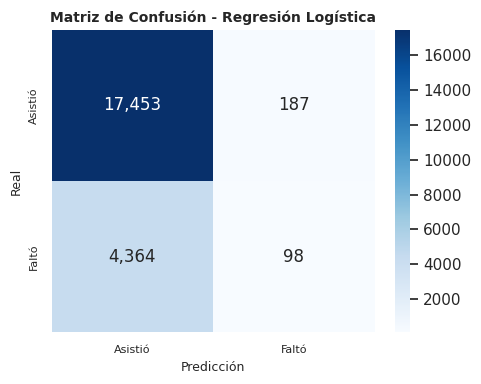

In [36]:
# Matriz de confusión

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', xticklabels=['Asistió', 'Faltó'],
            yticklabels=['Asistió', 'Faltó'], ax=ax, annot_kws={'fontsize': 12})
ax.set_xlabel('Predicción', fontsize=9)
ax.set_ylabel('Real', fontsize=9)
ax.set_title('Matriz de Confusión - Regresión Logística', fontweight='bold', fontsize=10)
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

**Análisis de resultados**

El modelo tiene un desempeño muy pobre para detectar inasistencias: solo identifica correctamente 98 de 4,462 pacientes que faltaron (Recall de 0.02 para la clase "Faltó"). Es decir, deja pasar al 98% de las inasistencias.

- **Accuracy (0.79):** alto, pero prácticamente igual a predecir siempre "Asistió".
- **Recall clase Faltó (0.02):** el modelo casi no detecta inasistencias
- **Precision clase Faltó (0.34):** cuando predice "Faltó", acierta solo 1 de cada 3 veces.
- **AUC-ROC (0.67):** capacidad discriminativa baja, apenas por encima del azar (0.50).

La Regresión Logística, al ser lineal, no logra capturar las relaciones no lineales e interacciones entre las variables. Las correlaciones bajas con el target, vistas anteriormente, explican por qué este modelo (que captura relaciones lineales) tuvo tan mal desempeño.


### 5.3 Modelo 2: Random Forest

Random Forest es un ensemble de árboles de decisión que combina múltiples árboles entrenados sobre subconjuntos aleatorios de datos y features. Se elige como segundo modelo porque:

- **Captura relaciones no lineales** e interacciones entre variables sin necesidad de definirlas explícitamente.
- **No requiere estandarización** de features, ya que los árboles de decisión trabajan con particiones ordinales.
- **Maneja bien el desbalance** cuando se ajusta el parámetro class_weight.
- **Provee importancia de features**, lo que permite interpretar qué variables contribuyen más a la predicción.

Se utiliza class_weight='balanced' para que el modelo penalice más los errores sobre la clase minoritaria (inasistencias), compensando el desbalance del dataset.

In [37]:
# Entrenamiento de Random Forest

rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf, target_names=['Asistió', 'Faltó']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_rf):.4f}")

              precision    recall  f1-score   support

     Asistió       0.81      0.97      0.89     17640
       Faltó       0.53      0.13      0.21      4462

    accuracy                           0.80     22102
   macro avg       0.67      0.55      0.55     22102
weighted avg       0.76      0.80      0.75     22102

AUC-ROC: 0.7438


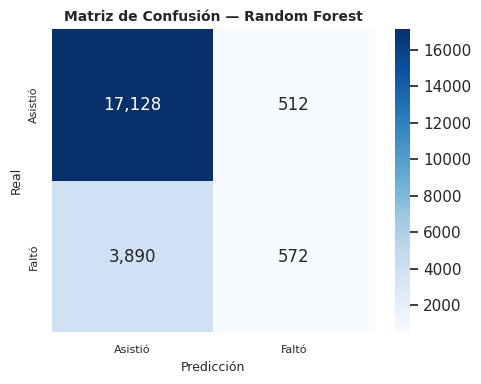

In [38]:
# Matriz de confusión

fig, ax = plt.subplots(figsize=(5, 4))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt=',d', cmap='Blues', xticklabels=['Asistió', 'Faltó'],
            yticklabels=['Asistió', 'Faltó'], ax=ax, annot_kws={'fontsize': 12})
ax.set_xlabel('Predicción', fontsize=9)
ax.set_ylabel('Real', fontsize=9)
ax.set_title('Matriz de Confusión — Random Forest', fontweight='bold', fontsize=10)
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

**Análisis de resultados**

Random Forest mejora respecto a la Regresión Logística, pero el desempeño sobre la clase "Faltó" sigue siendo insuficiente:

- **AUC-ROC (0.74):** mejora significativa respecto a la Regresión Logística (0.67), indicando mejor capacidad discriminativa general.
- **Recall clase Faltó (0.13):** detecta 572 de 4,462 inasistencias, 6 veces más que la Regresión Logística (98), pero aún deja pasar el 87% de los casos.
- **Precision clase Faltó (0.53):** cuando predice "Faltó", acierta la mitad de las veces.
- **F1 clase Faltó (0.21):** el balance entre precision y recall sigue siendo bajo.

El modelo prioriza no equivocarse al predecir "Faltó" (precision aceptable) pero a costa de ser muy conservador y detectar pocas inasistencias.

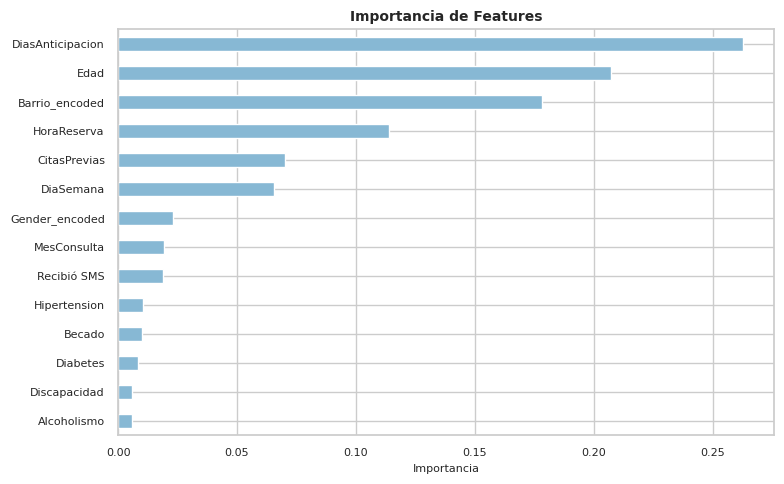

In [39]:
# Importancia de features

importances = pd.Series(rf.feature_importances_, index=features).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', color='#87b8d4', edgecolor='white', ax=ax)
ax.set_title('Importancia de Features', fontweight='bold', fontsize=10)
ax.set_xlabel('Importancia', fontsize=8)
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

**Importancia de features:**

Se confirman los hallazgos de la exploración:
- **DiasAnticipacion** es la feature más importante por lejos.
- **Edad** y **Barrio_encoded** son la segunda y tercera más relevantes, capturando factores demográficos y socioeconómicos.
- **HoraReserva** y **CitasPrevias** (features derivadas) aportan información significativa, validando la ingeniería de variables.
- Las condiciones médicas (**Hipertensión, Diabetes, Alcoholismo, Discapacidad**) y el **SMS** tienen importancia marginal.

### 5.4 Modelo 3: Gradient Boosting (XGBoost)

A diferencia de Random Forest que entrena árboles en paralelo de forma independiente, Gradient Boosting construye árboles secuencialmente, donde cada nuevo árbol intenta corregir los errores del anterior. XGBoost es una implementación optimizada de este enfoque que incluye regularización para evitar sobreajuste. Se utiliza scale_pos_weight para compensar el desbalance de clases.

In [40]:
# Ratio de desbalance para scale_pos_weight
ratio = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(n_estimators=200, scale_pos_weight=ratio, random_state=42,
                     eval_metric='logloss', use_label_encoder=False)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb, target_names=['Asistió', 'Faltó']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_xgb):.4f}")

              precision    recall  f1-score   support

     Asistió       0.90      0.63      0.74     17640
       Faltó       0.33      0.72      0.45      4462

    accuracy                           0.65     22102
   macro avg       0.61      0.67      0.59     22102
weighted avg       0.78      0.65      0.68     22102

AUC-ROC: 0.7412


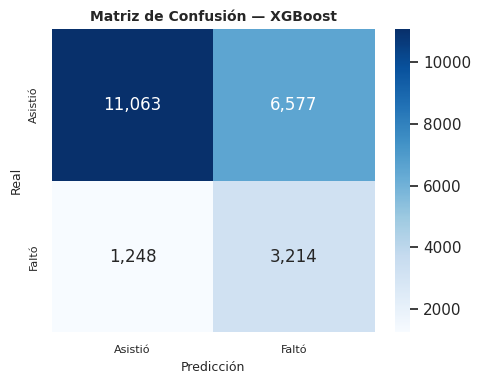

In [41]:
# Matriz de confusión

fig, ax = plt.subplots(figsize=(5, 4))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt=',d', cmap='Blues', xticklabels=['Asistió', 'Faltó'],
            yticklabels=['Asistió', 'Faltó'], ax=ax, annot_kws={'fontsize': 12})
ax.set_xlabel('Predicción', fontsize=9)
ax.set_ylabel('Real', fontsize=9)
ax.set_title('Matriz de Confusión — XGBoost', fontweight='bold', fontsize=10)
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

**Análisis de resultados**

XGBoost muestra un comportamiento radicalmente diferente a los modelos anteriores:

- **Recall clase Faltó (0.72):** detecta 3,214 de 4,462 inasistencias, una mejora enorme respecto a Random Forest (0.13) y Regresión Logística (0.02).
- **Precision clase Faltó (0.33):** el costo de ese mayor recall es que 2 de cada 3 predicciones de "Faltó" son falsas alarmas (6,577 falsos positivos).
- **AUC-ROC (0.74):** similar al Random Forest, lo que indica capacidad discriminativa comparable.
- **Accuracy (0.65):** menor que los otros modelos, pero esto refleja el trade-off: el modelo sacrifica accuracy global para detectar más inasistencias.

**Trade-off clave:** XGBoost prioriza no dejar pasar inasistencias (pocas falsas negativas: 1,248) a costa de generar más falsas alarmas (6,577). Desde la perspectiva del sistema de salud, una falsa alarma (llamar a un paciente que sí iba a asistir) tiene mucho menor costo que no detectar una inasistencia (perder el turno médico). Por esto, este trade-off es favorable para el problema.

### 5.5 Modelo 4: LightGBM

LightGBM es otra implementación de Gradient Boosting que utiliza un algoritmo de crecimiento de árboles basado en histogramas, lo que lo hace más eficiente en memoria y velocidad que XGBoost. Además, crece los árboles por hoja en lugar de por nivel, lo que puede capturar patrones más complejos.

In [42]:
# Entrenamiento de LightGBM

lgbm = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    is_unbalance=True,
    random_state=42,
    verbose=-1
)
lgbm.fit(X_train, y_train)

y_pred_lgbm = lgbm.predict(X_test)
y_prob_lgbm = lgbm.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_lgbm, target_names=['Asistió', 'Faltó']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_lgbm):.4f}")

              precision    recall  f1-score   support

     Asistió       0.92      0.57      0.70     17640
       Faltó       0.32      0.80      0.45      4462

    accuracy                           0.62     22102
   macro avg       0.62      0.68      0.58     22102
weighted avg       0.80      0.62      0.65     22102

AUC-ROC: 0.7458


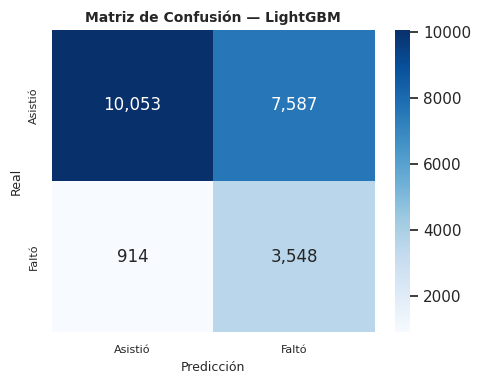

In [43]:
# Matriz de confusión

fig, ax = plt.subplots(figsize=(5, 4))
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)
sns.heatmap(cm_lgbm, annot=True, fmt=',d', cmap='Blues', xticklabels=['Asistió', 'Faltó'],
            yticklabels=['Asistió', 'Faltó'], ax=ax, annot_kws={'fontsize': 12})
ax.set_xlabel('Predicción', fontsize=9)
ax.set_ylabel('Real', fontsize=9)
ax.set_title('Matriz de Confusión — LightGBM', fontweight='bold', fontsize=10)
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

**Análisis de resultados**

LightGBM muestra un comportamiento similar a XGBoost, confirmando que los modelos de boosting son los más efectivos para este problema. Con is_unbalance=True logra un Recall de 0.80, detectando 3,548 de 4,462 inasistencias.

- **Recall (0.80):** levemente superior a XGBoost (0.72), lo que sugiere que LightGBM maneja el desbalance de forma más agresiva por defecto.
- **Precision (0.32):** similar a XGBoost, alrededor de 1 de cada 3 alertas es correcta.
- **AUC-ROC (0.746):** prácticamente idéntico, confirmando que ambos algoritmos extraen información similar del dataset.

### 5.6 Resumen comparativo

| Modelo | Recall (Faltó) | Precision (Faltó) | F1 (Faltó) | AUC-ROC |
|---|---|---|---|---|
| Regresión Logística | 0.02 | 0.34 | 0.04 | 0.666 |
| Random Forest | 0.13 | 0.53 | 0.21 | 0.744 |
| XGBoost | 0.72 | 0.33 | 0.45 | 0.741 |
| LightGBM | 0.80 | 0.32 | 0.45 | 0.746 |

Los modelos de boosting (XGBoost y LightGBM) superan claramente a la Regresión Logística y al Random Forest en la detección de inasistencias. Entre ellos, LightGBM obtiene el mejor Recall (0.80) y AUC-ROC (0.746) de base, mientras que XGBoost queda muy cerca. Se procederá a optimizar ambos modelos de boosting en el siguiente capítulo para buscar el mejor rendimiento posible.

## 6. Optimización y análisis avanzado

Tras comparar los 4 modelos base, los dos modelos de Gradient Boosting (XGBoost y LightGBM) se destacaron claramente como los más efectivos. En este capítulo se busca mejorar su rendimiento mediante optimización de hiperparámetros, análisis del umbral de decisión y selección de features por importancia.

### 6.1 Optimización de XGBoost

Se utiliza RandomizedSearchCV con 40 iteraciones y validación cruzada de 3 folds. La métrica de optimización es F1, buscando el mejor balance entre Recall y Precision para la clase "Faltó". Se elige RandomizedSearchCV sobre GridSearchCV por ser más eficiente computacionalmente dado el espacio de hiperparámetros a explorar.

In [44]:
# Optimización de hiperparámetros - XGBoost

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'scale_pos_weight': [ratio, ratio*0.75, ratio*0.5, ratio*1.25]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False),
    param_distributions=param_dist,
    n_iter=40,
    scoring='f1',
    cv=3,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

print(f"\nMejores hiperparámetros:")
for param, val in xgb_search.best_params_.items():
    print(f"  {param}: {val}")
print(f"\nMejor F1 en CV: {xgb_search.best_score_:.4f}")

Fitting 3 folds for each of 40 candidates, totalling 120 fits

Mejores hiperparámetros:
  subsample: 0.6
  scale_pos_weight: 3.9531066166171773
  n_estimators: 500
  min_child_weight: 5
  max_depth: 7
  learning_rate: 0.01
  colsample_bytree: 0.6

Mejor F1 en CV: 0.4537


In [45]:
# Evaluación del modelo optimizado

best_xgb = xgb_search.best_estimator_

y_pred_best = best_xgb.predict(X_test)
y_prob_best = best_xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_best, target_names=['Asistió', 'Faltó']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_best):.4f}")

              precision    recall  f1-score   support

     Asistió       0.92      0.55      0.69     17640
       Faltó       0.31      0.82      0.45      4462

    accuracy                           0.60     22102
   macro avg       0.62      0.68      0.57     22102
weighted avg       0.80      0.60      0.64     22102

AUC-ROC: 0.7457


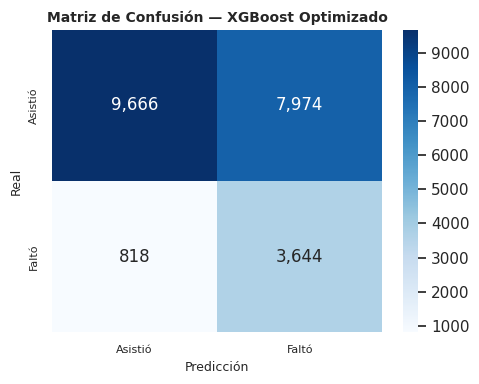

In [46]:
# Matriz de confusión - XGBoost Optimizado

fig, ax = plt.subplots(figsize=(5, 4))
cm_best = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm_best, annot=True, fmt=',d', cmap='Blues', xticklabels=['Asistió', 'Faltó'],
            yticklabels=['Asistió', 'Faltó'], ax=ax, annot_kws={'fontsize': 12})
ax.set_xlabel('Predicción', fontsize=9)
ax.set_ylabel('Real', fontsize=9)
ax.set_title('Matriz de Confusión — XGBoost Optimizado', fontweight='bold', fontsize=10)
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

**Análisis de resultados**

La optimización logró aumentar el Recall de 0.72 a 0.82, detectando ahora 3,644 de 4,462 inasistencias (430 más que antes). Sin embargo, la Precision bajó de 0.33 a 0.31, y el F1 se mantuvo en 0.45.

Comparación XGBoost base vs optimizado:

| Métrica | Base | Optimizado |
|---|---|---|
| Recall (Faltó) | 0.72 | **0.82** |
| Precision (Faltó) | 0.33 | 0.31 |
| F1 (Faltó) | 0.45 | 0.45 |
| AUC-ROC | 0.7412 | **0.7457** |
| Falsos negativos | 1,248 | **818** |
| Falsos positivos | 6,577 | 7,974 |

La optimización empujó el modelo hacia un perfil aún más agresivo en detección: redujo los falsos negativos de 1,248 a 818 (pacientes que faltan y no detectamos), a costa de aumentar los falsos positivos. Desde el punto de vista del negocio, esto es positivo: se pierden menos turnos médicos, y el costo de una llamada preventiva innecesaria es bajo comparado con el de una consulta desperdiciada.

### 6.2 Análisis del umbral de decisión

Los modelos de clasificación utilizan por defecto un umbral de 0.50 para decidir la clase. Sin embargo, ajustar este umbral permite controlar el trade-off entre Precision y Recall según las necesidades del negocio. Se analiza la curva Precision-Recall del XGBoost optimizado para encontrar el umbral que maximiza el F1.

In [47]:
# Análisis del umbral de decisión - XGBoost Optimizado

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_best)

# Calcular F1 para cada umbral
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Umbral por defecto: 0.50")
print(f"Umbral óptimo (max F1): {best_threshold:.3f}")
print(f"F1 en umbral óptimo: {f1_scores[best_idx]:.4f}")
print(f"Precision en umbral óptimo: {precisions[best_idx]:.4f}")
print(f"Recall en umbral óptimo: {recalls[best_idx]:.4f}")

Umbral por defecto: 0.50
Umbral óptimo (max F1): 0.527
F1 en umbral óptimo: 0.4578
Precision en umbral óptimo: 0.3263
Recall en umbral óptimo: 0.7665


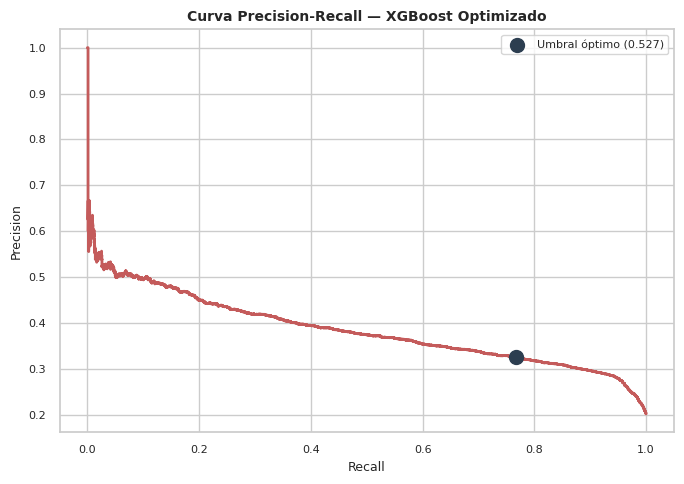

In [48]:
# Curva Precision-Recall con umbral óptimo marcado

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recalls, precisions, color='#c45b5b', lw=2)
ax.scatter(recalls[best_idx], precisions[best_idx], color='#2c3e50', s=100, zorder=5,
           label=f'Umbral óptimo ({best_threshold:.3f})')
ax.set_xlabel('Recall', fontsize=9)
ax.set_ylabel('Precision', fontsize=9)
ax.set_title('Curva Precision-Recall — XGBoost Optimizado', fontweight='bold', fontsize=10)
ax.legend(fontsize=8)
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

In [49]:
# Evaluación con umbral optimizado

y_pred_umbral = (y_prob_best >= best_threshold).astype(int)

print(classification_report(y_test, y_pred_umbral, target_names=['Asistió', 'Faltó']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_best):.4f}")

              precision    recall  f1-score   support

     Asistió       0.91      0.60      0.72     17640
       Faltó       0.33      0.77      0.46      4462

    accuracy                           0.63     22102
   macro avg       0.62      0.68      0.59     22102
weighted avg       0.79      0.63      0.67     22102

AUC-ROC: 0.7457


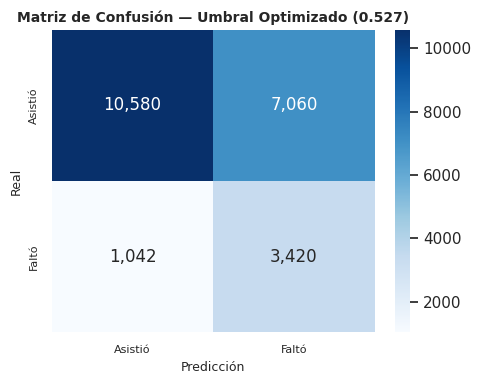

In [50]:
# Matriz de confusión con umbral optimizado

fig, ax = plt.subplots(figsize=(5, 4))
cm_umbral = confusion_matrix(y_test, y_pred_umbral)
sns.heatmap(cm_umbral, annot=True, fmt=',d', cmap='Blues', xticklabels=['Asistió', 'Faltó'],
            yticklabels=['Asistió', 'Faltó'], ax=ax, annot_kws={'fontsize': 12})
ax.set_xlabel('Predicción', fontsize=9)
ax.set_ylabel('Real', fontsize=9)
ax.set_title(f'Matriz de Confusión — Umbral Optimizado ({best_threshold:.3f})', fontweight='bold', fontsize=10)
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

**Análisis de resultados**

Se buscó el umbral de clasificación que maximiza el F1-Score sobre la curva Precision-Recall. El umbral óptimo encontrado es 0.527, apenas por encima del 0.50 por defecto.

| Métrica | Umbral 0.50 | Umbral 0.527 |
|---|---|---|
| Recall (Faltó) | 0.82 | 0.77 |
| Precision (Faltó) | 0.31 | 0.33 |
| F1 (Faltó) | 0.45 | 0.46 |


La mejora en F1 es marginal (+0.01). La curva Precision-Recall muestra tensión: para superar 0.75 de Recall, la Precision cae. Esto confirma que la principal limitación no es el umbral sino la capacidad discriminativa del modelo con las features disponibles, reflejada en un AUC-ROC de 0.746 que se mantiene independientemente del umbral elegido.

### 6.3 Optimización de LightGBM

Se aplica el mismo proceso de RandomizedSearchCV a LightGBM para comparar ambos modelos de boosting en su mejor versión.

In [51]:
# Optimización de hiperparámetros - LightGBM

param_dist_lgbm = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10, -1],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_samples': [5, 10, 20, 50],
    'is_unbalance': [True],
    'num_leaves': [15, 31, 63, 127]
}

lgbm_search = RandomizedSearchCV(
    lgb.LGBMClassifier(random_state=42, verbose=-1),
    param_distributions=param_dist_lgbm,
    n_iter=40,
    scoring='f1',
    cv=3,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

lgbm_search.fit(X_train, y_train)

print(f"\nMejores hiperparámetros:")
for param, val in lgbm_search.best_params_.items():
    print(f"  {param}: {val}")
print(f"\nMejor F1 en CV: {lgbm_search.best_score_:.4f}")

Fitting 3 folds for each of 40 candidates, totalling 120 fits

Mejores hiperparámetros:
  subsample: 0.9
  num_leaves: 63
  n_estimators: 200
  min_child_samples: 20
  max_depth: 7
  learning_rate: 0.05
  is_unbalance: True
  colsample_bytree: 0.6

Mejor F1 en CV: 0.4532


In [52]:
# Evaluación del LightGBM optimizado

best_lgbm = lgbm_search.best_estimator_

y_pred_lgbm_best = best_lgbm.predict(X_test)
y_prob_lgbm_best = best_lgbm.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_lgbm_best, target_names=['Asistió', 'Faltó']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_lgbm_best):.4f}")

              precision    recall  f1-score   support

     Asistió       0.92      0.56      0.69     17640
       Faltó       0.32      0.82      0.46      4462

    accuracy                           0.61     22102
   macro avg       0.62      0.69      0.58     22102
weighted avg       0.80      0.61      0.65     22102

AUC-ROC: 0.7457


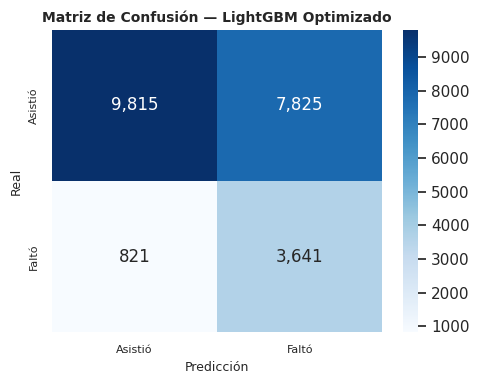

In [53]:
# Matriz de confusión - LightGBM Optimizado

fig, ax = plt.subplots(figsize=(5, 4))
cm_lgbm_best = confusion_matrix(y_test, y_pred_lgbm_best)
sns.heatmap(cm_lgbm_best, annot=True, fmt=',d', cmap='Blues', xticklabels=['Asistió', 'Faltó'],
            yticklabels=['Asistió', 'Faltó'], ax=ax, annot_kws={'fontsize': 12})
ax.set_xlabel('Predicción', fontsize=9)
ax.set_ylabel('Real', fontsize=9)
ax.set_title('Matriz de Confusión — LightGBM Optimizado', fontweight='bold', fontsize=10)
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

**Análisis de resultados — LightGBM Optimizado:**

Los resultados son prácticamente idénticos al XGBoost optimizado:

| Métrica | XGBoost Optim. | LightGBM Optim. |
|---|---|---|
| Recall (Faltó) | 0.82 | 0.82 |
| Precision (Faltó) | 0.31 | 0.32 |
| F1 (Faltó) | 0.45 | 0.46 |
| AUC-ROC | 0.7457 | 0.7457 |
| Falsos negativos | 818 | 821 |
| Falsos positivos | 7,974 | 7,825 |
| Mejor F1 en CV | 0.4537 | 0.4532 |

Ambos modelos optimizados convergen a métricas iguales.

### 6.4 Selección de features por importancia


En las secciones anteriores se entrenaron los modelos con las 14 features disponibles, manteniendo todas bajo el argumento de que los modelos de árboles realizan selección implícita. Sin embargo, un modelo con menos variables tiene ventajas prácticas: es más fácil de interpretar, más rápido de ejecutar en producción, y potencialmente menos propenso al sobreajuste si algunas features solo agregan ruido.

Para evaluar esto, se consulta el ranking de importancia del LightGBM optimizado y se seleccionan las **6 features más influyentes**, que coinciden en gran medida con el análisis SHAP realizado posteriormente:

1. **Edad**: factor demográfico clave, los jóvenes faltan más.
2. **Barrio_encoded**: captura el efecto geográfico/socioeconómico.
3. **HoraReserva**: patrón de comportamiento al momento de reservar.
4. **CitasPrevias**: familiaridad con el sistema de salud.
5. **DiasAnticipacion**: el predictor más fuerte identificado en la exploración.
6. **DiaSemana**: variabilidad leve pero consistente.

Se reentrenan con los mismos hiperparámetros optimizados para aislar el efecto de la reducción de features.

In [54]:
# Top features según importancia del modelo

importances_lgbm = pd.Series(best_lgbm.feature_importances_, index=features).sort_values(ascending=False)
print("Importancia de features — LightGBM Optimizado:\n")
print(importances_lgbm.to_string())

Importancia de features — LightGBM Optimizado:

Edad                2562
Barrio_encoded      2125
HoraReserva         1387
CitasPrevias        1230
DiasAnticipacion    1197
DiaSemana           1008
MesConsulta          516
Gender_encoded       419
Hipertension         309
Discapacidad         263
Recibió SMS          240
Becado               232
Alcoholismo          228
Diabetes             217


In [55]:
# Reentrenamiento con las 6 features más importantes

top_features = importances_lgbm.head(6).index.tolist()

X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

lgbm_top = lgb.LGBMClassifier(**lgbm_search.best_params_, random_state=42, verbose=-1)
lgbm_top.fit(X_train_top, y_train)

y_pred_top = lgbm_top.predict(X_test_top)
y_prob_top = lgbm_top.predict_proba(X_test_top)[:, 1]

print(classification_report(y_test, y_pred_top, target_names=['Asistió', 'Faltó']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_top):.4f}")

              precision    recall  f1-score   support

     Asistió       0.92      0.54      0.68     17640
       Faltó       0.31      0.82      0.45      4462

    accuracy                           0.60     22102
   macro avg       0.62      0.68      0.57     22102
weighted avg       0.80      0.60      0.64     22102

AUC-ROC: 0.7415


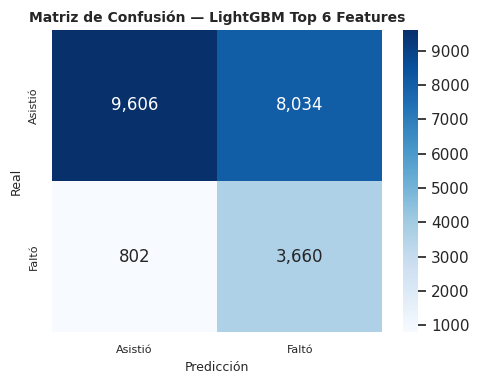

In [56]:
# Matriz de confusión - LightGBM Top Features

fig, ax = plt.subplots(figsize=(5, 4))
cm_top = confusion_matrix(y_test, y_pred_top)
sns.heatmap(cm_top, annot=True, fmt=',d', cmap='Blues', xticklabels=['Asistió', 'Faltó'],
            yticklabels=['Asistió', 'Faltó'], ax=ax, annot_kws={'fontsize': 12})
ax.set_xlabel('Predicción', fontsize=9)
ax.set_ylabel('Real', fontsize=9)
ax.set_title('Matriz de Confusión — LightGBM Top 6 Features', fontweight='bold', fontsize=10)
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

**Análisis — LightGBM con Top 6 Features:**

| Métrica | 14 Features | 6 Features |
|---|---|---|
| Recall (Faltó) | 0.82 | 0.82 |
| Precision (Faltó) | 0.32 | 0.31 |
| F1 (Faltó) | 0.46 | 0.45 |
| AUC-ROC | 0.7457 | 0.7415 |
| Falsos negativos | 821 | 802 |
| Falsos positivos | 7,825 | 8,034 |

El modelo con solo 6 features mantiene prácticamente el mismo rendimiento que el de 14. El Recall se mantiene en 0.82 y el AUC-ROC baja apenas de 0.746 a 0.742, una diferencia despreciable. Incluso los falsos negativos mejoran levemente (802 vs 821).

Esto confirma dos cosas:
1. **Las 6 features principales concentran casi toda la información predictiva** del dataset. Las 8 restantes (Gender, Becado, Hipertensión, Diabetes, Alcoholismo, Discapacidad, Recibió SMS, MesConsulta) aportan muy poco al modelo.
2. **Un modelo más simple y con menos variables** podría implementarse en producción con las mismas prestaciones, facilitando el mantenimiento.

### 6.5 Comparación final y validación cruzada

Para cerrar el análisis, se comparan todos los modelos optimizados con validación cruzada estratificada de 5 folds, obteniendo estimaciones robustas del rendimiento con intervalos de confianza.

In [57]:
# Comparación de modelos optimizados: Validación cruzada

modelos_finales = {
    'Reg. Logística': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost Optim.': xgb_search.best_estimator_,
    'LightGBM Optim.': lgbm_search.best_estimator_
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

resultados = []
for nombre, modelo in modelos_finales.items():
    if nombre == 'Reg. Logística':
        scores = cross_validate(modelo, scaler.fit_transform(X), y, cv=cv,
                                scoring=['f1', 'roc_auc', 'recall', 'precision'], n_jobs=-1)
    else:
        scores = cross_validate(modelo, X, y, cv=cv,
                                scoring=['f1', 'roc_auc', 'recall', 'precision'], n_jobs=-1)

    resultados.append({
        'Modelo': nombre,
        'F1': f"{scores['test_f1'].mean():.3f} ± {scores['test_f1'].std():.3f}",
        'AUC-ROC': f"{scores['test_roc_auc'].mean():.3f} ± {scores['test_roc_auc'].std():.3f}",
        'Recall': f"{scores['test_recall'].mean():.3f} ± {scores['test_recall'].std():.3f}",
        'Precision': f"{scores['test_precision'].mean():.3f} ± {scores['test_precision'].std():.3f}"
    })

print(pd.DataFrame(resultados).to_string(index=False))

         Modelo            F1       AUC-ROC        Recall     Precision
 Reg. Logística 0.035 ± 0.004 0.668 ± 0.005 0.019 ± 0.002 0.340 ± 0.037
  Random Forest 0.194 ± 0.001 0.740 ± 0.004 0.120 ± 0.001 0.515 ± 0.011
 XGBoost Optim. 0.456 ± 0.002 0.745 ± 0.003 0.816 ± 0.008 0.316 ± 0.001
LightGBM Optim. 0.456 ± 0.003 0.746 ± 0.002 0.810 ± 0.008 0.317 ± 0.002


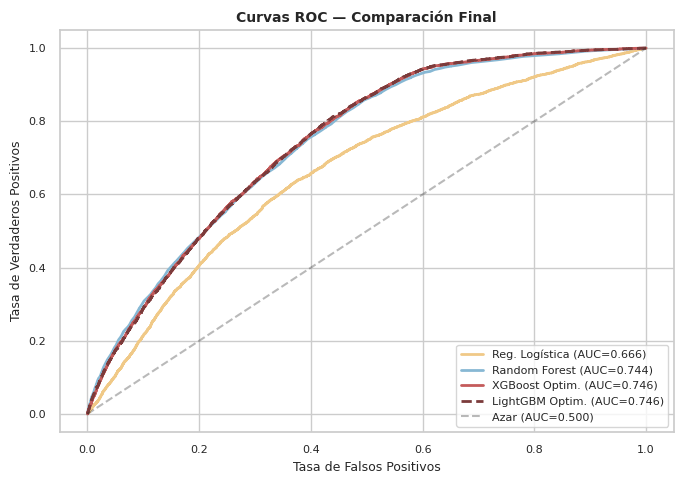

In [58]:
# Curvas ROC - Todos los modelos

fig, ax = plt.subplots(figsize=(7, 5))

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_best)
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, y_prob_lgbm_best)

ax.plot(fpr_lr, tpr_lr, color='#f0c987', lw=2, label=f'Reg. Logística (AUC={roc_auc_score(y_test, y_prob_lr):.3f})')
ax.plot(fpr_rf, tpr_rf, color='#87b8d4', lw=2, label=f'Random Forest (AUC={roc_auc_score(y_test, y_prob_rf):.3f})')
ax.plot(fpr_xgb, tpr_xgb, color='#c45b5b', lw=2, label=f'XGBoost Optim. (AUC={roc_auc_score(y_test, y_prob_best):.3f})')
ax.plot(fpr_lgbm, tpr_lgbm, color='#7b3b3b', lw=2, ls='--', label=f'LightGBM Optim. (AUC={roc_auc_score(y_test, y_prob_lgbm_best):.3f})')
ax.plot([0,1], [0,1], 'k--', alpha=0.3, label='Azar (AUC=0.500)')

ax.set_xlabel('Tasa de Falsos Positivos', fontsize=9)
ax.set_ylabel('Tasa de Verdaderos Positivos', fontsize=9)
ax.set_title('Curvas ROC — Comparación Final', fontweight='bold', fontsize=10)
ax.legend(fontsize=8, loc='lower right')
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

**Análisis**

La curva ROC grafica la relación entre la Tasa de Verdaderos Positivos (Recall) y la Tasa de Falsos Positivos a distintos umbrales de clasificación. Un modelo perfecto se ubicaría en la esquina superior izquierda; un modelo aleatorio seguiría la diagonal.

- **Reg. Logística (AUC=0.666):** la curva más cercana a la diagonal, confirmando su pobre capacidad discriminativa.
- **Random Forest (AUC=0.744):** mejora significativa, se separa claramente de la diagonal.
- **XGBoost y LightGBM (AUC=0.746):** las curvas se superponen casi perfectamente entre sí. Se separan del Random Forest en la zona media de la curva (FPR entre 0.2 y 0.6), donde logran mayor Recall para la misma tasa de falsos positivos.

El AUC de 0.746 indica una capacidad discriminativa moderada; siendo aceptable.

### 6.6 Interpretabilidad con SHAP

SHAP (SHapley Additive exPlanations) permite entender no solo qué variables son importantes, sino cómo y en qué dirección afectan cada predicción individual. A diferencia de la importancia de features del modelo (que solo mide magnitud), SHAP muestra si valores altos de una feature aumentan o disminuyen la probabilidad de inasistencia.

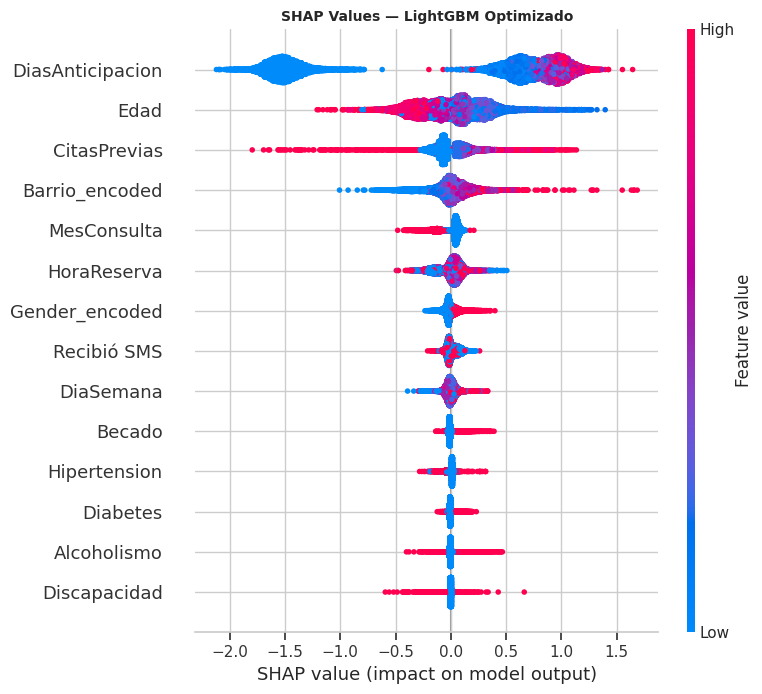

In [59]:
# SHAP values

explainer = shap.TreeExplainer(best_lgbm)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

fig, ax = plt.subplots(figsize=(8, 5))
shap.summary_plot(shap_vals, X_test, feature_names=features, show=False, max_display=14)
plt.title('SHAP Values — LightGBM Optimizado', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()

**Interpretación del gráfico SHAP:**

Cada punto representa una predicción individual. El color indica el valor de la feature (rojo = alto, azul = bajo) y la posición horizontal indica cuánto empuja esa feature hacia la predicción de inasistencia (derecha) o asistencia (izquierda).

- **DiasAnticipacion:** el patrón más claro, valores altos (rojo, a la derecha) aumentan fuertemente la probabilidad de inasistencia. Es la feature con mayor dispersión, confirmando su rol dominante.
- **Edad:** valores bajos (azul, a la derecha) aumentan el riesgo, es decir, los pacientes jóvenes tienen mayor probabilidad de faltar. Valores altos (rojo, a la izquierda) lo disminuyen.
- **CitasPrevias:** alta dispersión hacia ambos lados, sugiriendo una relación no lineal con el target.
- **Barrio_encoded:** barrios con alta tasa histórica de inasistencia (rojo) empujan la predicción hacia "Faltó".
- **Hipertensión:** valores altos (rojo = tiene hipertensión) empujan hacia la izquierda (asistencia), confirmando que los hipertensos faltan menos.
- Las features inferiores (Diabetes, Alcoholismo, Discapacidad) tienen impacto mínimo, concentradas cerca de cero.

Esta interpretabilidad es fundamental para la implementación práctica: permite explicar al equipo médico *por qué* el modelo marca a un paciente específico como riesgo, generando confianza en la herramienta.

### 6.7 Ejemplo de aplicación

Para ilustrar cómo se utilizaría el modelo en la práctica, se muestra una predicción individual sobre un paciente del conjunto de test.

In [60]:
# Ejemplo de predicción individual

ejemplo = X_test.iloc[0:1]
prob = best_lgbm.predict_proba(ejemplo)[0][1]

print("=== Ejemplo de predicción ===\n")
print("Datos del paciente:")
for feat, val in zip(features, ejemplo.values[0]):
    print(f"  {feat}: {val}")
print(f"\nProbabilidad de inasistencia: {prob*100:.1f}%")
print(f"Clasificación: {'Riesgo de inasistencia' if prob >= 0.5 else 'Probable asistencia'}")
print(f"Resultado real: {'Faltó' if y_test.iloc[0] == 1 else 'Asistió'}")

=== Ejemplo de predicción ===

Datos del paciente:
  Gender_encoded: 0.0
  Edad: 22.0
  Becado: 0.0
  Hipertension: 0.0
  Diabetes: 0.0
  Alcoholismo: 0.0
  Discapacidad: 0.0
  Recibió SMS: 0.0
  DiasAnticipacion: 2.0
  DiaSemana: 4.0
  MesConsulta: 5.0
  HoraReserva: 11.0
  CitasPrevias: 0.0
  Barrio_encoded: 0.1957142857142857

Probabilidad de inasistencia: 62.9%
Clasificación: Riesgo de inasistencia
Resultado real: Faltó


**Interpretación del ejemplo:**

El modelo predice correctamente que esta paciente faltará a la consulta, con una probabilidad del 62.9%. Los factores que más pesan en esta predicción son:
- **Edad de 22 años** — adulta joven, el rango etario con mayor tasa de inasistencia.
- **Sin citas previas** — primera vez en el sistema, sin historial de adherencia.
- **Barrio con tasa del 19.6%** — cercana al promedio.

En la práctica, el sistema de salud recibiría esta alerta y podría contactar a la paciente para confirmar su asistencia antes.

## 7. Análisis y Discusión de Resultados



### 7.1 Validación cruzada

La validación cruzada estratificada (5-Fold) confirma la robustez de los resultados con baja varianza entre folds:

| Modelo | F1 | AUC-ROC | Recall | Precision |
|---|---|---|---|---|
| Reg. Logística | 0.035 ± 0.004 | 0.668 ± 0.005 | 0.019 ± 0.002 | 0.340 ± 0.037 |
| Random Forest | 0.194 ± 0.001 | 0.740 ± 0.004 | 0.120 ± 0.001 | 0.515 ± 0.011 |
| XGBoost Optim. | 0.456 ± 0.002 | 0.745 ± 0.003 | 0.816 ± 0.008 | 0.316 ± 0.001 |
| LightGBM Optim. | 0.456 ± 0.003 | 0.746 ± 0.002 | 0.810 ± 0.008 | 0.317 ± 0.002 |

Las desviaciones estándar muy bajas (± 0.002–0.008) indican que los modelos generalizan de manera consistente y no dependen de una partición particular de los datos.

### 7.2 Modelo seleccionado

Tanto XGBoost como LightGBM optimizados alcanzan métricas prácticamente idénticas. Se selecciona LightGBM Optimizado (14 features) como modelo final por su leve ventaja en AUC-ROC (0.746 vs 0.745) y Precision (0.317 vs 0.316), aunque la diferencia es marginal. En la práctica, ambos serían equivalentes.

El experimento de selección de features (sección 6.4) demostró que un modelo con solo las 6 features más importantes alcanza un rendimiento casi idéntico (AUC-ROC 0.742 vs 0.746, Recall 0.82 en ambos). Esto significa que, si se priorizara simplicidad en una implementación en producción, se podría usar el modelo reducido con una pérdida despreciable de rendimiento.

### 7.3 Interpretación desde el negocio

El modelo final detecta el 81% de las inasistencias (Recall = 0.810 en CV). Traducido a la operativa del sistema de salud:

- De cada 100 pacientes que van a faltar, el modelo identifica correctamente a 81; se les puede llamar, reasignar el turno o aplicar sobre-reserva.
- De cada 100 alertas que genera el modelo, 32 son correctas y 68 son falsas alarmas; pacientes que sí iban a asistir reciben una llamada preventiva innecesaria, un costo bajo y sin consecuencias negativas.
- Solo 19 de cada 100 inasistencias pasan sin ser detectadas.

En un contexto donde un turno médico desperdiciado tiene un costo significativo (hora profesional, infraestructura, paciente en lista de espera), y una llamada preventiva tiene un costo marginal, este trade-off es claramente favorable.

### 7.4 Variables más influyentes

Los modelos, el análisis SHAP y el experimento de selección de features coinciden en los principales factores de inasistencia:

1. **Días de anticipación**: predictor dominante. Las citas del mismo día tienen 4.7% de no-show vs 33% para citas a más de 30 días.
2. **Edad**: pacientes jóvenes (adolescentes y adultos jóvenes) faltan más que adultos mayores.
3. **Barrio**: proxy de factores socioeconómicos y de accesibilidad geográfica.
4. **Hora de reserva y citas previas**: variables derivadas en el feature engineering que demostraron alto poder predictivo.
5. **Día de la semana**: variabilidad leve pero capturada por los modelos de árboles.

Las condiciones médicas (Hipertensión, Diabetes, Alcoholismo, Discapacidad), el género, el programa Becado y el SMS resultaron tener importancia marginal, confirmado tanto por SHAP como por el hecho de que eliminar estas 8 variables no afectó el rendimiento del modelo (sección 6.4).


### 7.5 Sobre el efecto del SMS

Un hallazgo relevante es que el SMS recordatorio no redujo la inasistencia en los datos observados, de hecho, los pacientes que recibieron SMS faltaron más (27.6% vs 16.7%). Esto se debe a un sesgo de selección (los SMS se enviaron probablemente a pacientes con citas más lejanas), confirmado por la correlación de 0.40 entre Recibió SMS y DiasAnticipacion observada en la matriz de correlación. Un modelo predictivo como el desarrollado podría complementar la estrategia de SMS, focalizando las intervenciones en los pacientes de mayor riesgo real.


### 7.6 Limitaciones

- **Precision baja (0.32):** genera muchas falsas alarmas. Aceptable para este caso de uso pero no para todos los escenarios.
- **Target encoding del barrio** calculado sobre todo el dataset introduce un leve data leakage.
- **Ventana temporal limitada** (2 meses, abril–junio 2016): no captura estacionalidad anual.
- **AUC-ROC de 0.746:** indica capacidad discriminativa moderada.

### 7.7 Trabajo futuro

Para superar el techo actual de rendimiento, sería necesario enriquecer el dataset con:
- **Historial de inasistencias previas** del paciente (la feature potencialmente más valiosa).
- **Especialidad médica** de la consulta.
- **Distancia** entre el domicilio del paciente y el centro de salud.
- **Condiciones climáticas** el día de la consulta.
- **Canal de reserva** (presencial, telefónico, online).

### 7.8 Conclusión

Se desarrolló un modelo de clasificación capaz de predecir con poco más de un 80% de recall las inasistencias a consultas médicas, utilizando exclusivamente información disponible al momento de la reserva.

El proyecto recorrió todas las etapas de un pipeline de machine learning: exploración y limpieza de datos, ingeniería de variables, entrenamiento y comparación de cuatro modelos (Regresión Logística, Random Forest, XGBoost y LightGBM), optimización de hiperparámetros, análisis de umbral de decisión, interpretabilidad con SHAP y selección de features por importancia.

Los modelos de Gradient Boosting (XGBoost y LightGBM) superaron claramente a los enfoques más simples, y la convergencia de ambos a métricas prácticamente idénticas (AUC-ROC ≈ 0.746). El experimento con 6 features confirmó que la mayor parte de la información predictiva se concentra en unas pocas variables clave, lo que facilita tanto la interpretación como una eventual implementación.

El modelo representa una herramienta concreta para que el sistema de salud pueda intervenir proactivamente, reduciendo turnos desperdiciados y optimizando la asignación de recursos médicos. La variable más determinante es la anticipación de la reserva, lo que sugiere que las intervenciones deberían focalizarse especialmente en pacientes con citas agendadas con varios días o semanas de anticipación, complementando la estrategia de SMS con acciones más focalizadas como llamadas telefónicas a los pacientes de mayor riesgo.